# Development and Characterization of a cont. FSM Controller  

In [1]:
%load_ext autoreload
%autoreload 2

## Imports and Definitions

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from diffpssi.tools import *

from diffpssi.power_sim_lib.backend import *
from diffpssi.power_sim_lib.testbench import TestBench as Tb
from diffpssi.power_sim_lib.simulator import Recorder

from diffpssi.power_sim_lib.models.transformer import *
from diffpssi.power_sim_lib.models.voltage_controller import *
from diffpssi.power_sim_lib.models.blocks import *

set_matplot_settings(
    font_family="Times New Roman",
    font_size=10,
)

In [4]:
def jump_input(t, a: float = 1, b: float = 1.3, threshold: float = 1):
    """Callable jump input function.

    Args:
        t (float or list): time instant(s)
        a (float, optional): value before threshold. Defaults to 1.
        b (float, optional): value after threshold. Defaults to 1.1.
        threshold (float, optional): time threshold. Defaults to 1.

    Returns:
        torch.tensor or list: jump value(s)
    """
    # Depending on input type, return single or list of jump values
    # Necessary for compatibility with Recorder class and simulator
    if isinstance(t, float):
        if t < threshold:
            jump = a * torch.ones((1, 1), dtype=torch.float64)
        else:
            jump = b * torch.ones((1, 1), dtype=torch.float64)
    else:  # isinstance(t, list):
        jump = []
        for i in t:
            if i < threshold:
                jump.append(a * torch.ones((1, 1), dtype=torch.float64))
            else:
                jump.append(b * torch.ones((1, 1), dtype=torch.float64))

        jump = torch.tensor(jump, dtype=torch.float64)

    return jump

In [5]:
def input_function(t, a: float = 0.1, b: float = 1.1):
    """Input function for the test bench simulation, respectively control block testing.

    Args:
        t (float or list): time instant(s)
        a (float, optional): exponential decay rate. Defaults to 0.1.
        b (float, optional): final value after decay. Defaults to 1.1.
    
    Returns:
        torch.tensor or list: input value(s)
    """

    # Depending on input type, return single or list of jump values
    # Necessary for compatibility with Recorder class and simulator
    if isinstance(t, float):
        a = torch.tensor(a, dtype=torch.float64)
        b = torch.tensor(b, dtype=torch.float64)
        input = (
            b - (b - 1) * torch.exp(-a * t) 
            # * torch.ones((1, 1), dtype=torch.float64)
        )
    else:
        a = torch.tensor(a, dtype=torch.float64)
        b = torch.tensor(b, dtype=torch.float64)
        input = []
        for i in t:
            input.append(
                b - (b - 1) 
                * torch.exp(-a * i)
                # * torch.ones((1, 1), dtype=torch.float64)
            )
        
        input = torch.tensor(input, dtype=torch.float64)

    
    return input

In [6]:
def duplet_input(t, a: float = 1, b: float = 0.3, t1: float = 1, t2: float = 5, td: float = 2):
    """Callable jump input function.
    Args:
        t (float or list): time instant(s)
        a (float, optional): value before threshold. Defaults to 1.
        b (float, optional): additional value after threshold. Defaults to 0.3.
        t1 (float, optional): start time threshold 1. Defaults to 1.
        t2 (float, optional): start time threshold 2. Defaults to 5.
        td (float, optional): duration between jumps. Defaults to 2.

    Returns:
        torch.tensor or list: jump value(s)
    """
    # Depending on input type, return single or list of jump values
    # Necessary for compatibility with Recorder class and simulator
    if isinstance(t, float):
        if t > t1 and t < t1 + td:
            jump = (a + b) * torch.ones((1, 1), dtype=torch.float64)
        elif t > t2 and t < t2 + td:
            jump = (a - b) * torch.ones((1, 1), dtype=torch.float64)
        else:
            jump = a * torch.ones((1, 1), dtype=torch.float64)
    else:  # isinstance(t, list):
        jump = []
        for i in t:
            if i > t1 and i < t1 + td:
                jump.append((a + b) * torch.ones((1, 1), dtype=torch.float64))
            elif i > t2 and i < t2 + td:
                jump.append((a - b) * torch.ones((1, 1), dtype=torch.float64))
            else:
                jump.append(a * torch.ones((1, 1), dtype=torch.float64))
        jump = torch.tensor(jump, dtype=torch.float64)
    return jump

## Set-Up of a Characterization

In [7]:
fsm_min = 0.76
fsm_max = 1.24
delta_m_fsm = 0.04

n_taps = int((fsm_max - fsm_min) / delta_m_fsm)

print(f"Number of taps: {n_taps}")
fsm_min + n_taps * delta_m_fsm

Number of taps: 12


1.24

In [8]:
analysis_models = [
    # [OLTC_Discrete(param_dict={
    #     "t_1": 5,
    #     "pt_1": 0,
    #     "db": 0.05,
    #     "time_sensitive": True,
    #     }), 1],
    # [OLTC_Continuous(param_dict={
    #     "t_1": 30.778,
    #     "gain_pt1": 0.944,
    #     # "db": 0,
    #     "m_min": 0.9,
    #     "m_max": 1.1,
    #     "v_ref": 1.0
    #     }), 1],
    [OLTC_Continuous_Milano(param_dict={
        "kd": 0.8,
        "ki": 0.2,
        # "db": 0,
        "m_min": 0.84,
        "m_max": 1.20,
        "v_ref": 1.0
        }), 1],
    # [OLTC_Continuous_PI(param_dict={
    #     "kp": 0.107,
    #     "ki": 0.053,
    #     # "db": 0,
    #     "lim": 0.1,
    #     "v_ref": 1.0
    #     }), 1],
    [FSM_Only_Discrete(param_dict={
        "t_1": 1,
        "db": 0.025,
        "delta_m": 0.04,
        "m_min": 0.84,
        "m_max": 1.20,
        "gamma": 3,
        }), 1],
]


def record_dict(simulation, call=False):
    record_dict = {
        "Continuous OLTC Lag (Milano) model": simulation.diff_models[0].u_l,
        "Discrete FSM model ONLY": simulation.diff_models[1].u_l,
        # "Discrete OLTC model": simulation.diff_models[0].u_l,
        # "Continuous OLTC PT1 Model":    simulation.diff_models[1].u_l,
        # "Continuous OLTC PI model": simulation.diff_models[3].u_l,
        # "Continuous FSM model ONLY": simulation.diff_models[5].u_l,
        
        # "v dead": simulation.diff_models[0].v_dead,
        # "v integ": simulation.diff_models[0].integ,
        # "v dead": simulation.diff_models[0].m,
        # "tap pos": simulation.diff_models[0].tap_pos_m,        
        # "tap pos": simulation.diff_models[0].u_l,        
        # "Integrator state": simulation.diff_models[0].integrator_m.state_1,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

In [9]:
parallel_sims = 3

tb = Tb(
    time_step=0.005,
    sim_time=20,
    inspection_models=analysis_models,
    # input_func=input_function,
    input_func=jump_input,
    # input_func=duplet_input,
    record_func=record_dict,
    default_runner="run_oltc_control",
    parallel_sims=parallel_sims,
)

# tb.diff_models[0].dir = -1
# tb.diff_models[1].dir = -1

# Set the continous parameter uniformly distributed
# tb.diff_models[1].pt1.t_pt1 = torch.tensor(
#     np.random.uniform(5, 100, (parallel_sims, 1)),
#     requires_grad=True,
#     dtype=torch.float64,
# )
# tb.diff_models[2].lag.ki = torch.tensor(
#     np.random.uniform(0.05, 0.2, (parallel_sims, 1)),
#     requires_grad=True,
#     dtype=torch.float64,
# )
# tb.diff_models[3].pi.k_i = torch.tensor(
#     np.random.uniform(0, 0.2, (parallel_sims, 1)),
#     requires_grad=True,
#     dtype=torch.float64,
# )

In [10]:
t, recorder = tb.run()
plot_results = recorder.detach()

record_list = tb.record_list()

100%|██████████| 4001/4001 [00:00<00:00, 5228.83it/s]

Dynamic simulation finished in 0.84 seconds


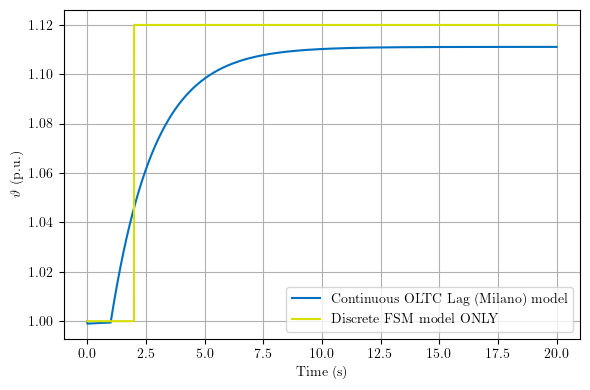

In [11]:
# Format shall be [batch, timestep, value]
plt.figure(figsize=(6,4))

# plt.plot(t, plot_results[0, :, 0], label=record_list[0])
for i in range(len(record_list)):
    plt.plot(t, plot_results[0, :, i], label=f"{record_list[i]}")

plt.legend()
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel(r"$\vartheta$ (p.u.)")
# plt.savefig("./data/oltc_control_characterization_presentation.pdf")
plt.show()

In [12]:
def loss_function(sim_results, target_values):
    """Loss function to optimize the controller parameters.

    Args:
        sim_results (torch.tensor): Simulation results from the test bench.
        target_value (float, optional): Target value for the output. Defaults to 1.0.

    Returns:
        torch.tensor: Computed loss value.
    """
    # sim_results shape: [batch, timestep, model]
    # target_values shape: [batch, timestep]
    # output should be shape: [batch]
    
    # Expand target_values to match sim_results shape for broadcasting
    # target_values = target_values.unsqueeze(2)

    # Compute the loss as the mean squared error between output and target value
    loss = torch.sum((sim_results - target_values) ** 2, axis=1)
    return loss

In [13]:
losses = []
for i in range(len(analysis_models)):
    losses.append(loss_function(
        sim_results=recorder[:, :, i],
        target_values=recorder[:, :, 0],
    ))

minimum = [torch.min(loss) for loss in losses]
idx_min = [torch.argmin(loss) for loss in losses]

idx_min

[tensor(0), tensor(0)]

In [14]:
# print(tb.diff_models[1].pt1.t_pt1[idx_min[1]])
# print(tb.diff_models[2].lag.ki[idx_min[2]])
# print(tb.diff_models[3].pi.k_i[idx_min[3]])

# loss_param_vector_pi = np.array([
#     tb.diff_models[3].pi.k_i[:, 0].detach().numpy(),
#     losses[3].detach().numpy()
#     ]
# )
# loss_param_vector_pt1 = np.array([
#     tb.diff_models[1].pt1.t_pt1[:, 0].detach().numpy(),
#     losses[1].detach().numpy()
#     ]
# )
# loss_param_vector_lag = np.array([
#     tb.diff_models[2].lag.ki[:, 0].detach().numpy(),
#     losses[2].detach().numpy()
#     ]
# )

In [15]:
# plt.plot(loss_param_vector_pi[0, :], loss_param_vector_pi[1, :], "o")
# plt.xlabel(r"Parameter $k_i$ for PI Controller")
# plt.ylabel("MSE")
# plt.grid()

In [16]:
# plt.plot(loss_param_vector_pt1[0, :], loss_param_vector_pt1[1, :], "o")
# plt.xlabel(r"Parameter $T_1$ for PT1 Controller")
# plt.ylabel("MSE")
# plt.grid()

In [17]:
# plt.plot(loss_param_vector_lag[0, :], loss_param_vector_lag[1, :], "o")
# plt.xlabel(r"Parameter $k_i$ for Lag Controller")
# plt.ylabel("MSE")
# plt.grid()

In [18]:
# # Format shall be [batch, timestep, value]
# plt.figure()

# plt.plot(t, plot_results[0, :, 0], label=record_list[0])
# for j in [0]: #[0, 20, 40, 60, 80]:
#     plt.plot(t, plot_results[idx_min[1], :, 1], label=f"{record_list[1]} sim {j}")
#     plt.plot(t, plot_results[idx_min[2], :, 2], label=f"{record_list[2]} sim {j}")
#     plt.plot(t, plot_results[idx_min[3], :, 3], label=f"{record_list[3]} sim {j}")

# plt.legend()
# plt.grid()
# plt.xlabel("Time (s)")
# plt.ylabel(r"$\vartheta$ (p.u.)")
# # plt.savefig("./data/oltc_control_characterization_presentation.pdf")
# plt.show()

In [19]:
times = tb.input_func(t).reshape(-1, 1, 1)
x_i = torch.swapaxes(times, 0, 1)
output = plot_results * x_i

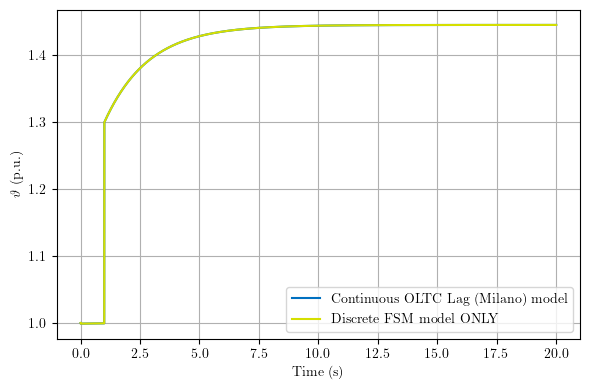

In [ ]:
# Format shall be [batch, timestep, value]
plt.figure(figsize=(6,4))

# plt.plot(t, plot_results[0, :, 0], label=record_list[0])
for i in range(len(record_list)):
    plt.plot(t, output[0, :, 0], label=f"{record_list[i]}")

plt.legend()
plt.grid()
plt.xlabel("Time (s)")
plt.ylabel(r"$\vartheta$ (p.u.)")
# plt.savefig("./data/oltc_control_characterization_presentation.pdf")

plt.show()